In [1]:
from pathlib import Path
import math
import torch
import matplotlib.pyplot as plt

In [ ]:
SPECIAL_TOKENS = {"<|vision_start|>", "<|image_pad|>", "<|vision_end|>", "<|im_start|>", "<|im_end|>", "system", "user", "assistant", "Ċ"}

def token_masks(tokens):
    text = torch.tensor([tok not in SPECIAL_TOKENS for tok in tokens], dtype=torch.bool)
    text[text.nonzero().flatten()[:6]] = False
    vision = torch.tensor([tok == "<|image_pad|>" for tok in tokens], dtype=torch.bool)
    return text, vision, text | vision

def get_debiased_importances(path, max_layers=20, alpha=0.5, beta=0.5, floor=1e-4):
    obj = torch.load(path, map_location="cpu")
    text_tokens, vision_tokens, prompt_tokens = token_masks(obj["tokens"])

    dtype, device = obj["attentions"][0].dtype, obj["attentions"][0].device

    n_prompt, n_vision = int(prompt_tokens.sum()), int(vision_tokens.sum())

    provenance0 = torch.zeros(n_prompt, n_vision, dtype=dtype, device=device)
    provenance0[vision_tokens[prompt_tokens]] = torch.eye(n_vision, dtype=dtype, device=device)

    prompt_idx, text_idx = torch.where(prompt_tokens)[0].to(device), torch.where(text_tokens)[0].to(device)

    prompt_reach = (prompt_idx[:, None] >= prompt_idx[None, :]).to(dtype)
    prompt_reach /= prompt_reach.sum(-1, keepdim=True).clamp_min(1e-12)

    text_reach = (text_idx[:, None] >= prompt_idx[None, :]).to(dtype)
    text_reach /= text_reach.sum(-1, keepdim=True).clamp_min(1e-12)

    I = torch.eye(n_prompt, dtype=dtype, device=device)

    provenances, baselines = [provenance0], [provenance0.clone()]

    baseline_scores, debiased_scores = [], []

    for layer in range(min(max_layers, len(obj["attentions"]))):
        if layer:
            A = obj["attentions"][layer - 1][0, :, prompt_tokens][:, :, prompt_tokens].mean(0)
            provenances.append((beta * I + (1 - beta) * A) @ provenances[-1])
            baselines.append((beta * I + (1 - beta) * prompt_reach) @ baselines[-1])

        text_attn = obj["attentions"][layer][0, :, text_tokens][:, :, prompt_tokens].mean(0)

        actual = text_attn @ provenances[-1]
        baseline = text_reach @ baselines[-1]

        debiased = actual / baseline.clamp_min(floor).pow(alpha)

        baseline_scores.append(baseline)
        debiased_scores.append(debiased / debiased.sum(-1, keepdim=True).clamp_min(1e-12))
        
    return torch.stack(baseline_scores), torch.stack(debiased_scores), text_tokens


In [3]:
def plot_importances(path, importances, layer, text_tokens, columns=3):
    obj = torch.load(path, map_location="cpu")
    scores = importances[layer].float()
    rows = math.ceil(scores.shape[0] / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3 * rows))
    axes = list(axes.flat) if hasattr(axes, "flat") else [axes]
    _, h, w = obj["image_grid_thw"][0].tolist()
    token_ids = text_tokens.nonzero().flatten().tolist()
    for k, ax in enumerate(axes):
        ax.axis("off")
        if k < scores.shape[0]:
            im = ax.imshow(scores[k].reshape(h // 2, w // 2), cmap="viridis", aspect="auto", vmin=scores.min(), vmax=scores.max())
            ax.set_title(f"{k}: {obj['tokens'][token_ids[k]]}")
    fig.colorbar(im, ax=axes, label="Attention score")
    plt.show()


In [ ]:
INPUT_DIR = Path("qwen_outputs")
OUTPUT_DIR = Path("importances_test")
OUTPUT_DIR.mkdir(exist_ok=True)
for path in sorted(INPUT_DIR.glob("sample_*.pt")):
    sample_id = path.stem.rsplit("_", 1)[-1]
    baseline, debiased, text_tokens = get_debiased_importances(path)
    torch.save(baseline, OUTPUT_DIR / f"baseline_importance_{sample_id}.pt")
    torch.save(debiased, OUTPUT_DIR / f"debiased_importance_{sample_id}.pt")
    print(sample_id, debiased.shape)


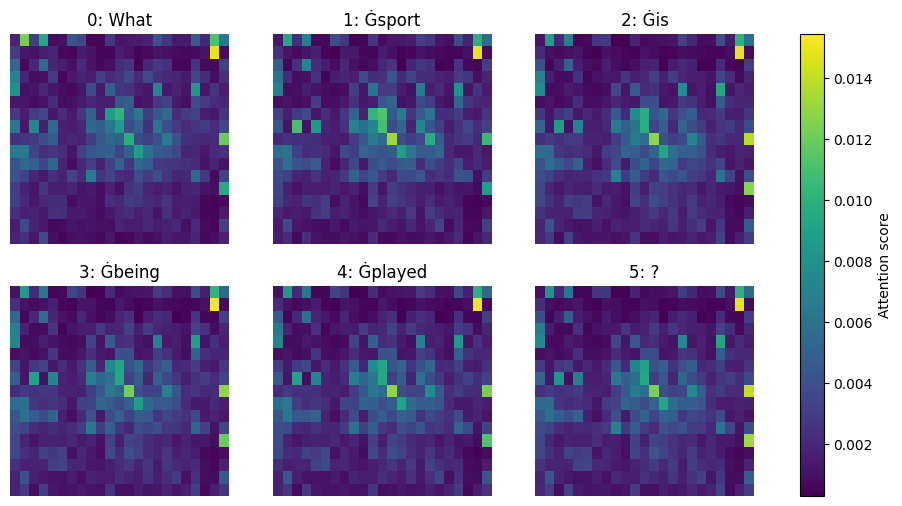

In [4]:
sample_path = Path("qwen_outputs/sample_192.pt")
baseline, debiased, text_tokens = get_debiased_importances(sample_path)
plot_importances(sample_path, debiased, layer=10, text_tokens=text_tokens)